# Diabetes Prediction Using Classification Models

## Problem Statement
The objective is to predict whether a patient has diabetes using demographic and medical information.

Three classification models will be trained and compared:

1. Logistic Regression
2. Decision Tree
3. Random Forest

The models will be evaluated using accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC.

In [5]:
# Libraries for data manipulation
import pandas as pd
import numpy as np

# Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

# Display all columns
pd.set_option("display.max_columns", None)

In [6]:
from google.colab import files

uploaded = files.upload()

Saving diabetes_prediction_dataset.csv to diabetes_prediction_dataset (1).csv


In [8]:
# Load the diabetes dataset
df = pd.read_csv("diabetes_prediction_dataset.csv")

# Display the first five rows
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [9]:
# Check the number of rows and columns
print("Dataset shape:", df.shape)

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

# Display dataset information
print("\nDataset information:")
df.info()

Dataset shape: (100000, 9)

Column names:
['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


## Dataset Variables

- `gender`: Gender of the patient
- `age`: Age of the patient
- `hypertension`: Whether the patient has hypertension
- `heart_disease`: Whether the patient has heart disease
- `smoking_history`: Patient's smoking history
- `bmi`: Body mass index
- `HbA1c_level`: Average blood sugar level over the previous few months
- `blood_glucose_level`: Current blood glucose measurement
- `diabetes`: Target variable, where 0 means no diabetes and 1 means diabetes

In [10]:
# Check missing values
print("Missing values in each column:")
print(df.isnull().sum())

# Check duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Missing values in each column:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Number of duplicate rows:
3854


In [11]:
# Remove exact duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)
print("Remaining duplicate rows:", df.duplicated().sum())

Dataset shape after removing duplicates: (96146, 9)
Remaining duplicate rows: 0


### Data Cleaning

No missing values were found in the dataset. Exact duplicate rows were removed so repeated patient records would not have unnecessary influence on model training.

In [12]:
# Count the target classes
class_counts = df["diabetes"].value_counts()

print("Target class counts:")
print(class_counts)

print("\nTarget class percentages:")
print((df["diabetes"].value_counts(normalize=True) * 100).round(2))

Target class counts:
diabetes
0    87664
1     8482
Name: count, dtype: int64

Target class percentages:
diabetes
0    91.18
1     8.82
Name: proportion, dtype: float64


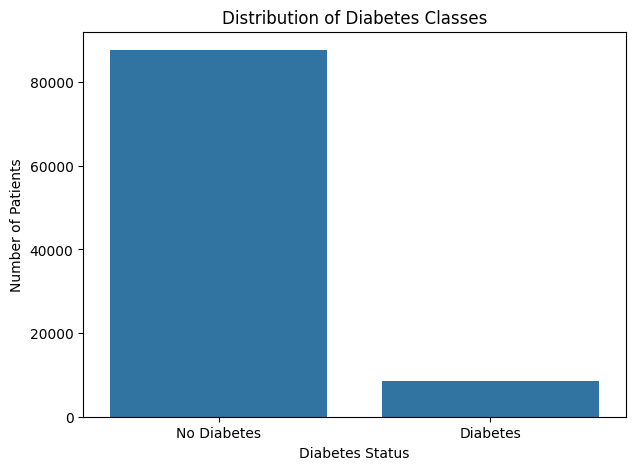

In [13]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="diabetes"
)

plt.title("Distribution of Diabetes Classes")
plt.xlabel("Diabetes Status")
plt.ylabel("Number of Patients")
plt.xticks([0, 1], ["No Diabetes", "Diabetes"])
plt.show()

### Target Distribution Observation

The dataset is imbalanced because the number of patients without diabetes is much larger than the number of patients with diabetes. Therefore, accuracy alone may be misleading, and metrics such as precision, recall, F1-score and ROC-AUC should also be considered.

In [14]:
# Display unique values in categorical columns
print("Gender values:")
print(df["gender"].unique())

print("\nSmoking history values:")
print(df["smoking_history"].unique())

Gender values:
['Female' 'Male' 'Other']

Smoking history values:
['never' 'No Info' 'current' 'former' 'ever' 'not current']


In [15]:
# Separate predictors and target variable
X = df.drop(columns=["diabetes"])
y = df["diabetes"]

print("Input feature shape:", X.shape)
print("Target shape:", y.shape)

Input feature shape: (96146, 8)
Target shape: (96146,)


In [16]:
# Identify numerical and categorical columns
numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']

Categorical columns:
['gender', 'smoking_history']


In [17]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining class percentages:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting class percentages:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training feature shape: (76916, 8)
Testing feature shape: (19230, 8)

Training class percentages:
diabetes
0    91.18
1     8.82
Name: proportion, dtype: float64

Testing class percentages:
diabetes
0    91.18
1     8.82
Name: proportion, dtype: float64


### Train-Test Split

The data was divided into 80% training data and 20% testing data. Stratified sampling was used so that the proportion of diabetic and non-diabetic patients remained similar in both sets.

In [18]:
# Scale numerical features
numerical_transformer = StandardScaler()

# Encode categorical features
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore"
)

# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['age', 'hypertension', 'heart_disease', 'bmi',
                                  'HbA1c_level', 'blood_glucose_level']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['gender', 'smoking_history'])])

In [19]:
# Logistic Regression pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Decision Tree pipeline
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

# Random Forest pipeline
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [20]:
# Train all three models
logistic_model.fit(X_train, y_train)
decision_tree_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

print("All three classification models trained successfully.")

All three classification models trained successfully.


In [21]:
# Predict diabetes classes on the test set
logistic_predictions = logistic_model.predict(X_test)
decision_tree_predictions = decision_tree_model.predict(X_test)
random_forest_predictions = random_forest_model.predict(X_test)

print("Predictions generated successfully.")


Predictions generated successfully.


In [22]:
# Predict probabilities for the positive class
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]
decision_tree_probabilities = decision_tree_model.predict_proba(X_test)[:, 1]
random_forest_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

print("Probability predictions generated successfully.")

Probability predictions generated successfully.


In [23]:
# Function to calculate classification metrics
def evaluate_classification_model(
    model_name,
    actual,
    predicted,
    probabilities
):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(actual, predicted),
        "Precision": precision_score(actual, predicted, zero_division=0),
        "Recall": recall_score(actual, predicted, zero_division=0),
        "F1-Score": f1_score(actual, predicted, zero_division=0),
        "ROC-AUC": roc_auc_score(actual, probabilities)
    }

In [24]:
# Evaluate the three classification models
results = []

results.append(
    evaluate_classification_model(
        "Logistic Regression",
        y_test,
        logistic_predictions,
        logistic_probabilities
    )
)

results.append(
    evaluate_classification_model(
        "Decision Tree",
        y_test,
        decision_tree_predictions,
        decision_tree_probabilities
    )
)

results.append(
    evaluate_classification_model(
        "Random Forest",
        y_test,
        random_forest_predictions,
        random_forest_probabilities
    )
)

# Create the comparison table
comparison_table = pd.DataFrame(results)

comparison_table

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.959646,0.869181,0.638561,0.736234,0.959896
1,Decision Tree,0.947946,0.691039,0.741156,0.715220,0.855501
2,Random Forest,0.969527,0.949757,0.691038,0.800000,0.956192


In [25]:
# Round metric values for easier reading
metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

comparison_table[metric_columns] = (
    comparison_table[metric_columns].round(4)
)

comparison_table

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9596,0.8692,0.6386,0.7362,0.9599
1,Decision Tree,0.9479,0.6910,0.7412,0.7152,0.8555
2,Random Forest,0.9695,0.9498,0.6910,0.8000,0.9562


In [26]:
# Rank the models by F1-score
comparison_table.sort_values(
    by="F1-Score",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.9695,0.9498,0.6910,0.8000,0.9562
1,Logistic Regression,0.9596,0.8692,0.6386,0.7362,0.9599
2,Decision Tree,0.9479,0.6910,0.7412,0.7152,0.8555


In [27]:
# Compare training and testing accuracy
generalization_table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Training Accuracy": [
        logistic_model.score(X_train, y_train),
        decision_tree_model.score(X_train, y_train),
        random_forest_model.score(X_train, y_train)
    ],
    "Testing Accuracy": [
        logistic_model.score(X_test, y_test),
        decision_tree_model.score(X_test, y_test),
        random_forest_model.score(X_test, y_test)
    ]
})

generalization_table["Accuracy Gap"] = (
    generalization_table["Training Accuracy"]
    - generalization_table["Testing Accuracy"]
)

generalization_table.round(4)

,Model,Training Accuracy,Testing Accuracy,Accuracy Gap
0,Logistic Regression,0.9587,0.9596,-0.0010
1,Decision Tree,0.9991,0.9479,0.0512
2,Random Forest,0.9991,0.9695,0.0296


In [28]:
print("Logistic Regression Classification Report")
print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=["No Diabetes", "Diabetes"],
        zero_division=0
    )
)

print("\nDecision Tree Classification Report")
print(
    classification_report(
        y_test,
        decision_tree_predictions,
        target_names=["No Diabetes", "Diabetes"],
        zero_division=0
    )
)

print("\nRandom Forest Classification Report")
print(
    classification_report(
        y_test,
        random_forest_predictions,
        target_names=["No Diabetes", "Diabetes"],
        zero_division=0
    )
)

Logistic Regression Classification Report
              precision    recall  f1-score   support

 No Diabetes       0.97      0.99      0.98     17534
    Diabetes       0.87      0.64      0.74      1696

    accuracy                           0.96     19230
   macro avg       0.92      0.81      0.86     19230
weighted avg       0.96      0.96      0.96     19230


Decision Tree Classification Report
              precision    recall  f1-score   support

 No Diabetes       0.97      0.97      0.97     17534
    Diabetes       0.69      0.74      0.72      1696

    accuracy                           0.95     19230
   macro avg       0.83      0.85      0.84     19230
weighted avg       0.95      0.95      0.95     19230


Random Forest Classification Report
              precision    recall  f1-score   support

 No Diabetes       0.97      1.00      0.98     17534
    Diabetes       0.95      0.69      0.80      1696

    accuracy                           0.97     19230
   macro avg

In [29]:
# Identify the model with the highest F1-score
best_model_row = comparison_table.loc[
    comparison_table["F1-Score"].idxmax()
]

print("Best model based on F1-score:")
print(best_model_row)

Best model based on F1-score:
Model        Random Forest
Accuracy            0.9695
Precision           0.9498
Recall               0.691
F1-Score               0.8
ROC-AUC             0.9562
Name: 2, dtype: object


In [30]:
# Get the name of the best model
best_model_name = best_model_row["Model"]

if best_model_name == "Logistic Regression":
    best_model = logistic_model
    best_predictions = logistic_predictions
    best_probabilities = logistic_probabilities

elif best_model_name == "Decision Tree":
    best_model = decision_tree_model
    best_predictions = decision_tree_predictions
    best_probabilities = decision_tree_probabilities

else:
    best_model = random_forest_model
    best_predictions = random_forest_predictions
    best_probabilities = random_forest_probabilities

print("Selected best model:", best_model_name)

Selected best model: Random Forest


In [31]:
# Calculate the confusion matrix
best_confusion_matrix = confusion_matrix(
    y_test,
    best_predictions
)

best_confusion_matrix

array([[17472,    62],
       [  524,  1172]])

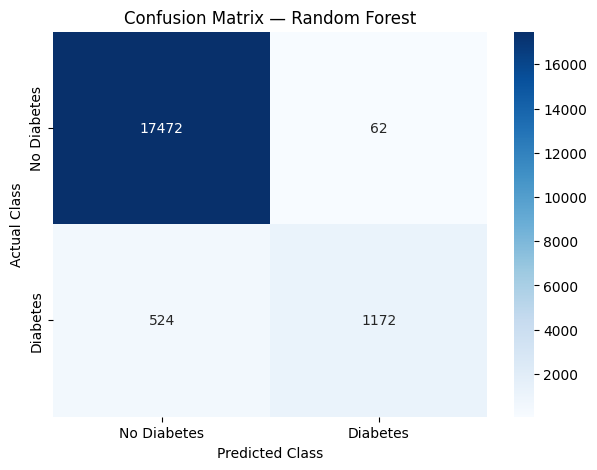

In [32]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    best_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)

plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

In [33]:
# Extract individual confusion-matrix values
tn, fp, fn, tp = best_confusion_matrix.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 17472
False Positives: 62
False Negatives: 524
True Positives: 1172


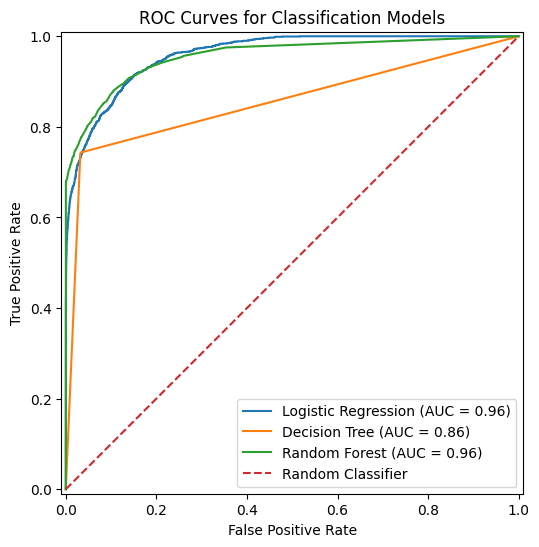

In [36]:
# Plot all ROC curves on the same graph
fig, ax = plt.subplots(figsize=(9, 6))

RocCurveDisplay.from_predictions(
    y_test,
    logistic_probabilities,
    name="Logistic Regression",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    decision_tree_probabilities,
    name="Decision Tree",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    random_forest_probabilities,
    name="Random Forest",
    ax=ax
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

ax.set_title("ROC Curves for Classification Models")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.show()

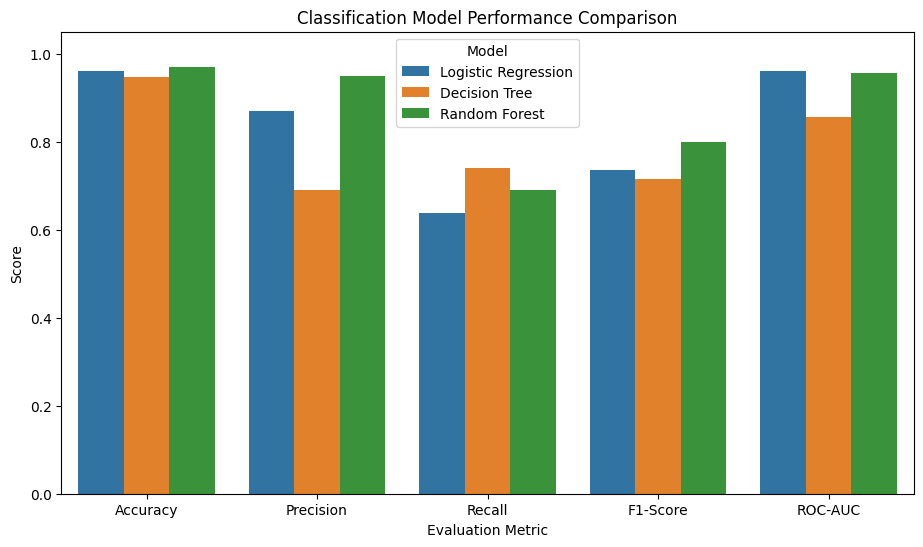

In [37]:
# Reshape the metrics table for visualization
metrics_plot_data = comparison_table.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=metrics_plot_data,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Classification Model Performance Comparison")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.legend(title="Model")
plt.show()

## Conclusion

Random Forest was selected as the best-performing model because it achieved the highest accuracy of 96.95%, precision of 94.98%, and F1-score of 0.80. Although the Decision Tree had slightly higher recall and Logistic Regression had slightly higher ROC-AUC, Random Forest provided the strongest overall balance between correctly identifying diabetic patients and avoiding false-positive predictions.

The confusion matrix shows that Random Forest correctly identified 1,172 diabetic patients and 17,472 non-diabetic patients, while producing only 62 false positives and 524 false negatives.